In [6]:
import cv2
import numpy as np
from PIL import Image

import os
import matplotlib.pyplot as plt

from skimage.feature import peak_local_max
from skimage.morphology import watershed

from scipy import ndimage

## 1 - Separate text from background

In [8]:
working_dir = 'text/'
files = next(os.walk(working_dir))[2]

In [9]:
images = []
for file in files:
     #read images from data folder
    img = cv2.imread(os.path.join(working_dir, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    images.append(img)

In [10]:
def visualize(images):
    for img in images:
        plt.figure(figsize=(15, 15))
        plt.imshow(img, cmap='gray')
        plt.axis('off')

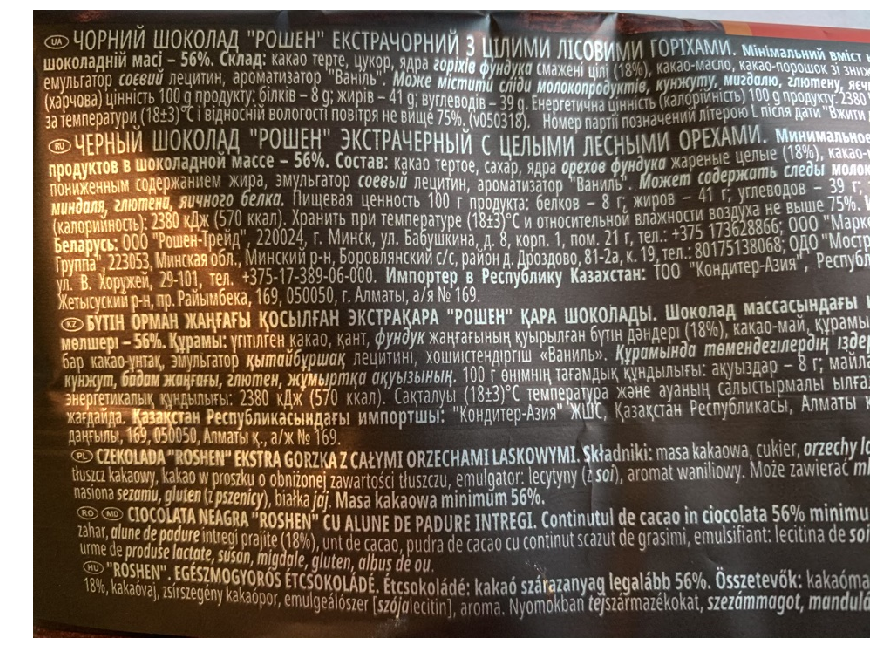

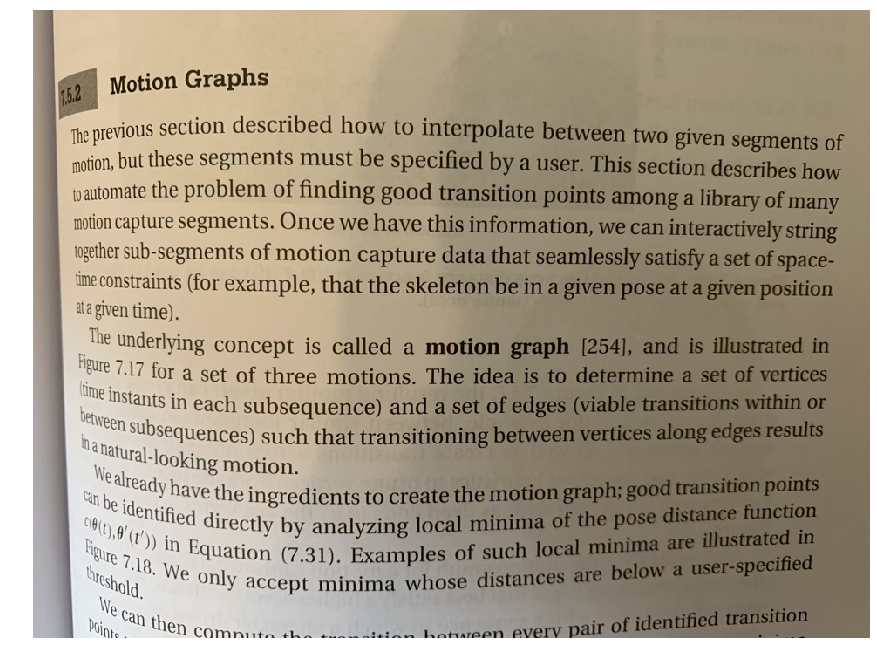

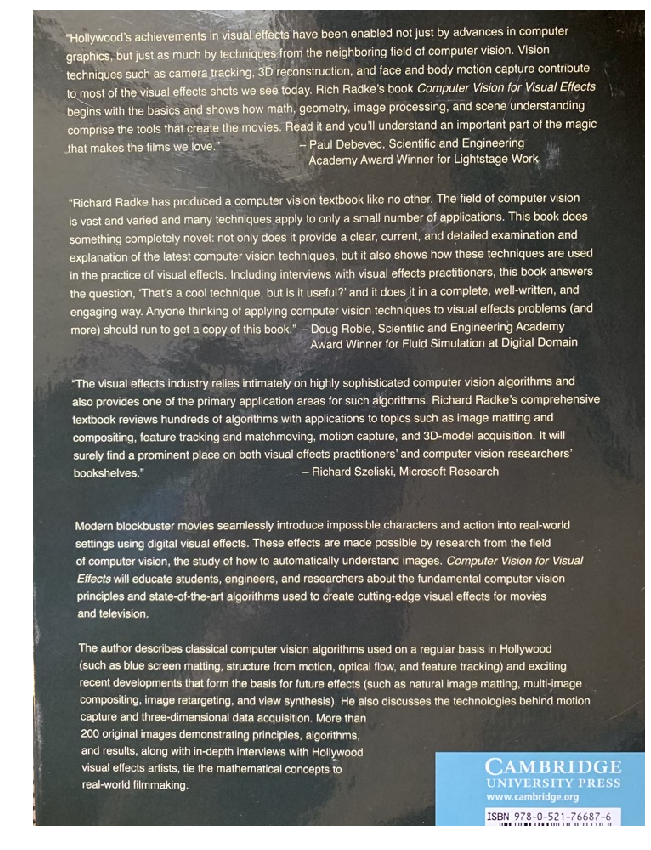

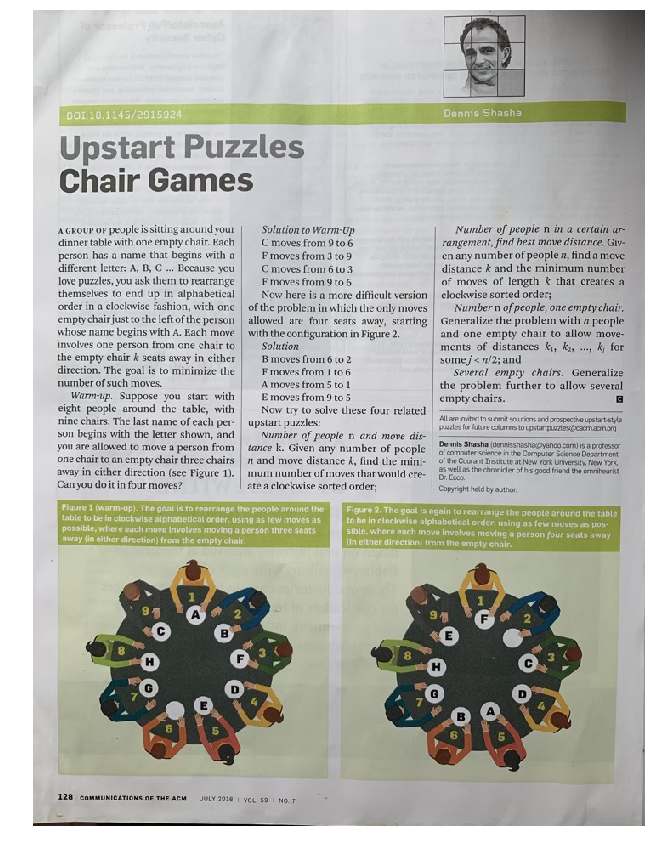

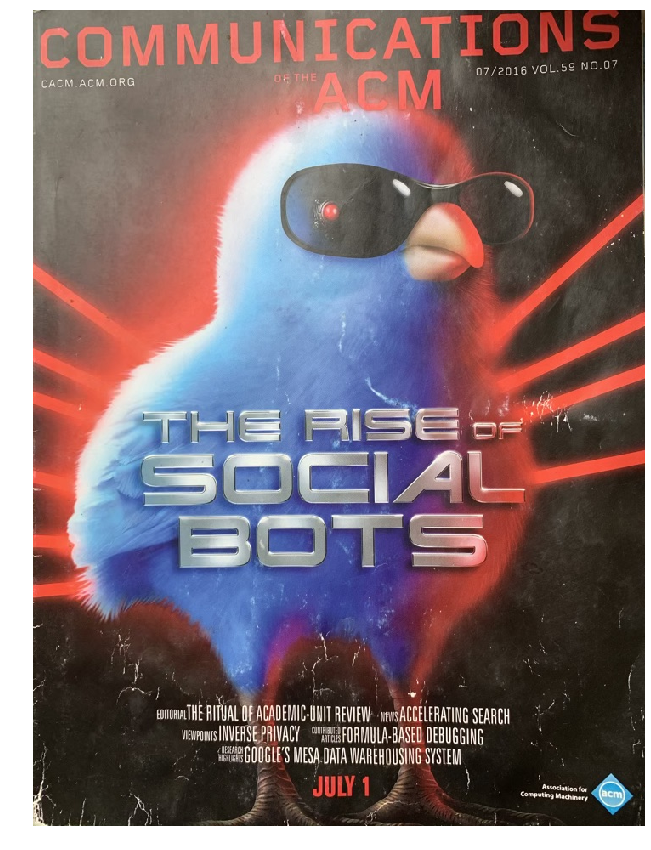

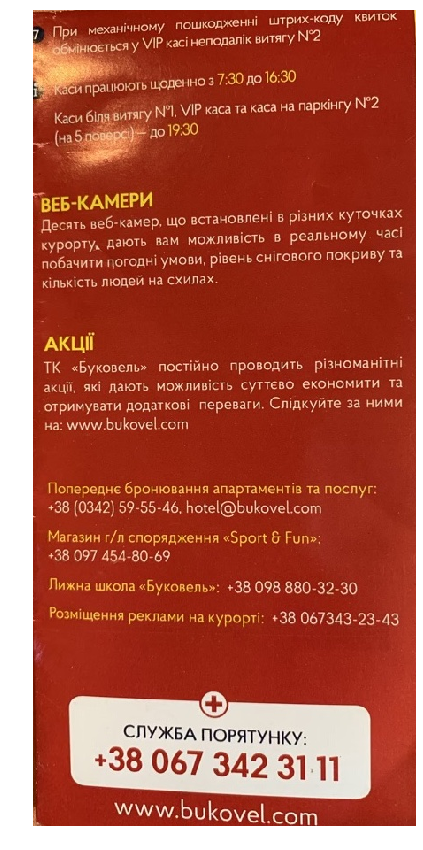

In [11]:
visualize(images)

In [12]:
def separate_text(img, n_patches_x=10, n_patches_y=3):
    
    # convert to grayscale
    grayscaled = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)    
    result = 255 * np.ones(grayscaled.shape, dtype=np.uint8)
    
    #number of parts of image that will be analyzed separately
    #the goal - handle text with different colors
    #there are will be n_patches_x * n_patches_y windows
    
    patch_size_x = grayscaled.shape[0] // n_patches_x
    patch_size_y = grayscaled.shape[1] // n_patches_y
    
    for i in range(n_patches_x):
        
        for j in range(n_patches_y):
            
            working_part = grayscaled[i*patch_size_x:(i+1)*patch_size_x, j*patch_size_y:(j+1)*patch_size_y]
            #compute threshold between background and text (suppose there are two classes)
            background_threshold, _ = cv2.threshold(working_part, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            
            #if quantile of intensities less than threshold, hence text is white
            if np.quantile(working_part, 0.3) < background_threshold:
                working_part = 255 - working_part
            
            # blur image and use adaptive threshold
            working_part = cv2.GaussianBlur(working_part, (3, 3), 0)
            output = cv2.adaptiveThreshold(working_part, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 5, 5)
            
            # post bluring
            output = cv2.GaussianBlur(output, (3, 3), 0)
            output = cv2.blur(output, (2, 2))
            
            # post thresholding
            _, output = cv2.threshold(output, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            result[i*patch_size_x:(i+1)*patch_size_x, j*patch_size_y:(j+1)*patch_size_y] = output

    return result

In [13]:
outputs = list(map(separate_text, images))

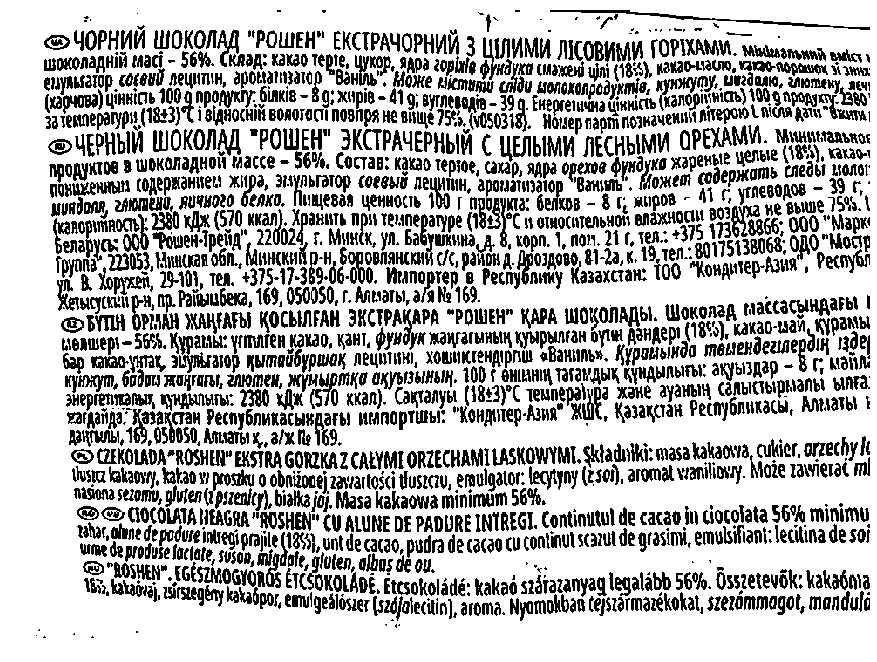

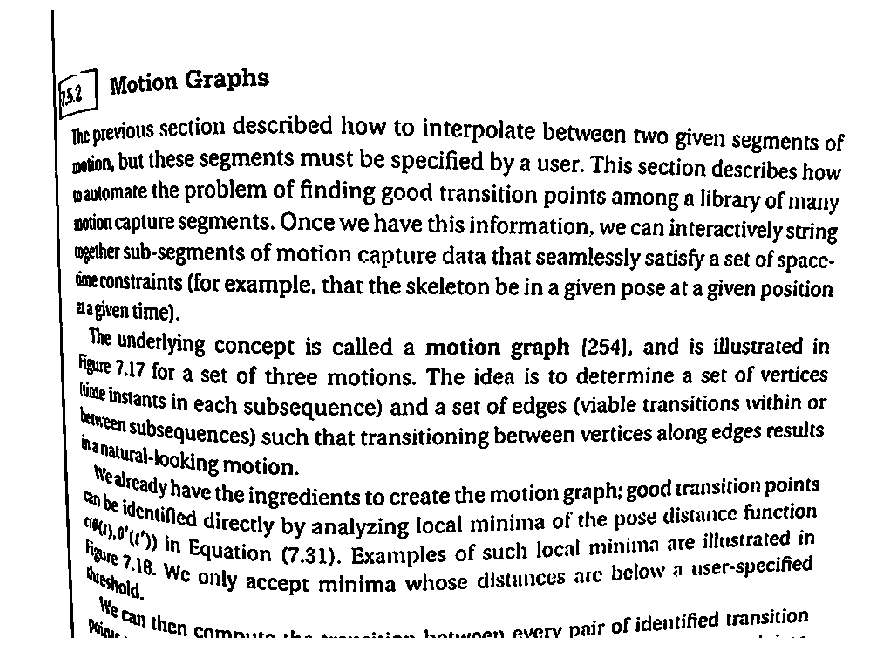

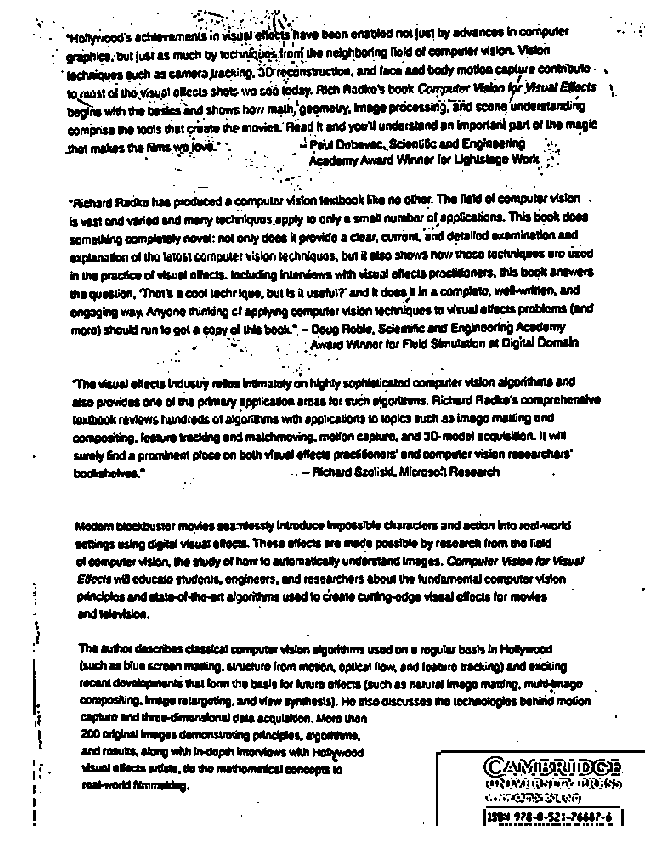

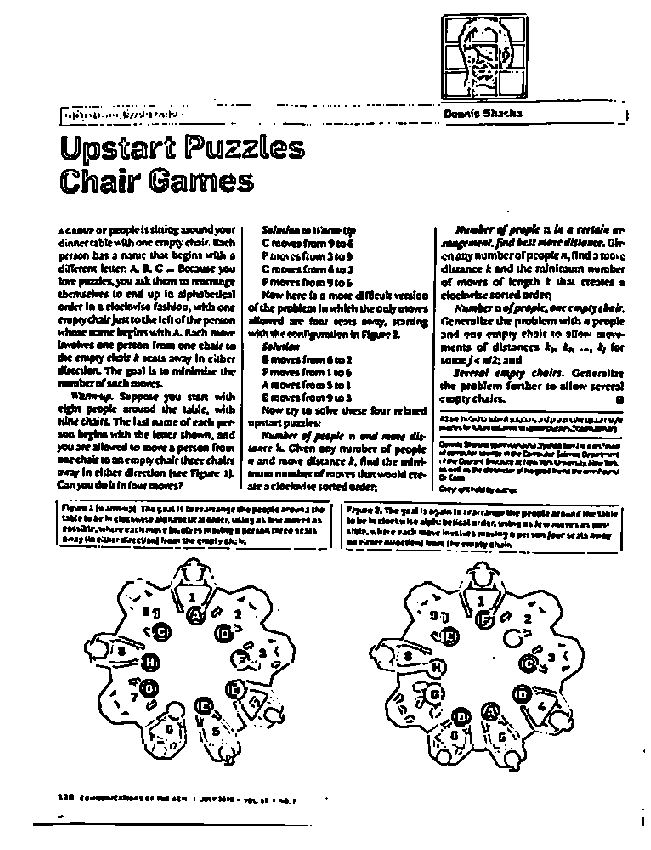

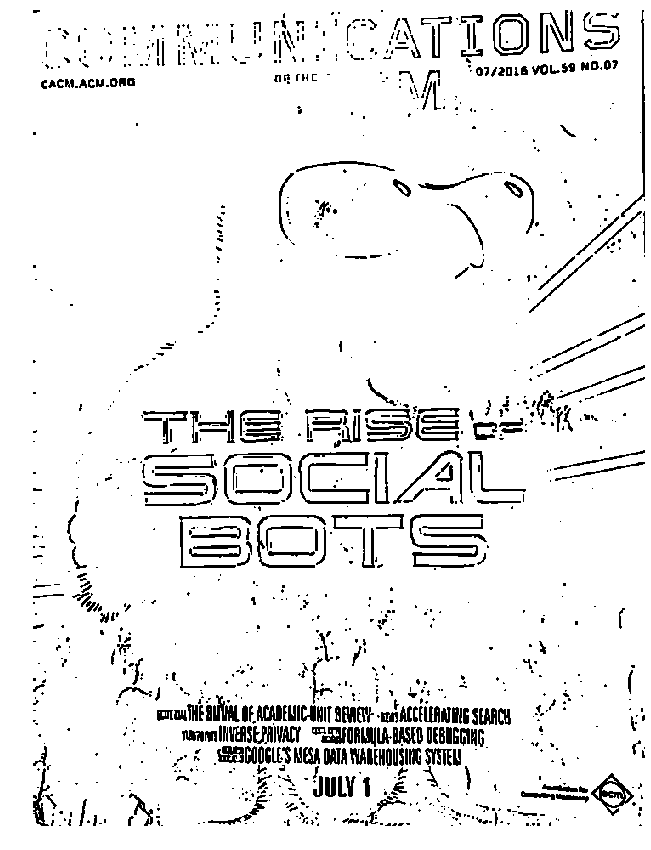

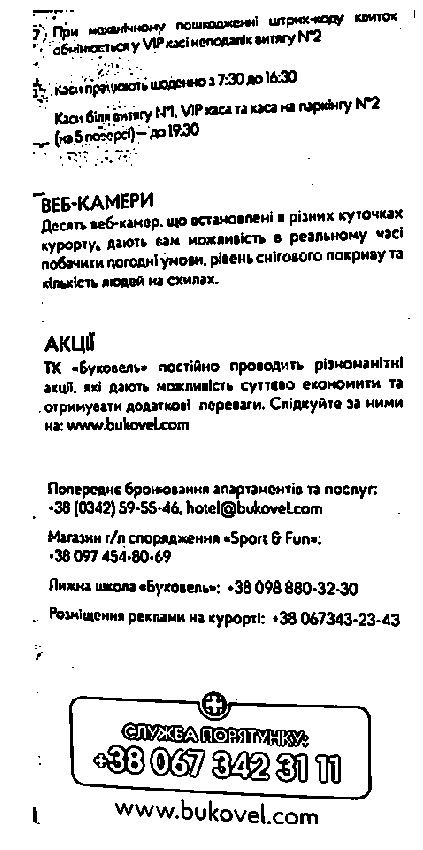

In [14]:
visualize(outputs)